# 06 exploratory data analysis

This notebook explores the disruption feature dataset before model training

The analysis checks

- dataset size and structure
- missing values
- severity distribution
- severity by time
- peak and non peak conditions
- routes with high severity
- important feature patterns
- model target distribution
- feature correlation

In [1]:
# import required libraries

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

python_path = sys.executable

spark = (
    SparkSession.builder
    .appName(
        "disruption_exploratory_data_analysis"
    )
    .config(
        "spark.sql.shuffle.partitions",
        "4"
    )
    .config(
        "spark.sql.session.timeZone",
        "Europe/London"
    )
    .config(
        "spark.pyspark.python",
        python_path
    )
    .config(
        "spark.pyspark.driver.python",
        python_path
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel(
    "WARN"
)

print(
    "spark session created"
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/16 22:52:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/16 22:52:08 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/07/16 22:52:08 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/07/16 22:52:08 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/07/16 22:52:08 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


spark session created


In [12]:
# define project folders

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

feature_parquet_path = (
    project_root
    / "data"
    / "processed"
    / "disruption_features"
)

model_parquet_path = (
    project_root
    / "data"
    / "processed"
    / "disruption_modelling_data"
)

feature_csv_path = (
    project_root
    / "data"
    / "processed"
    / "disruption_features_csv"
)

model_csv_path = (
    project_root
    / "data"
    / "processed"
    / "disruption_modelling_data_csv"
)

eda_output_path = (
    project_root
    / "data"
    / "processed"
    / "eda_outputs"
)

visualization_folder = (
    project_root
    / "visualizations"
    / "eda"
)

eda_output_path.mkdir(
    parents=True,
    exist_ok=True
)

visualization_folder.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "project root:",
    project_root
)

print(
    "feature parquet exists:",
    feature_parquet_path.exists()
)

print(
    "model parquet exists:",
    model_parquet_path.exists()
)

print(
    "visualization folder:",
    visualization_folder
)

project root: /Users/babitaadhikari/Desktop/bus-disruption-platform
feature parquet exists: True
model parquet exists: True
visualization folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda


In [13]:
# load the parquet datasets created in notebook 05

feature_parquet_df = (
    spark.read.parquet(
        str(
            feature_parquet_path
        )
    )
)

model_parquet_df = (
    spark.read.parquet(
        str(
            model_parquet_path
        )
    )
)

# save the feature dataset as csv

(
    feature_parquet_df
    .repartition(
        4,
        "line_ref"
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            feature_csv_path
        )
    )
)

# save the modelling dataset as csv

(
    model_parquet_df
    .repartition(
        4,
        "line_ref"
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            model_csv_path
        )
    )
)

print(
    "feature csv created"
)

print(
    "modelling csv created"
)

[Stage 99:=============================>                            (2 + 2) / 4]

feature csv created
modelling csv created


In [14]:
# load the feature csv dataset

feature_df = (
    spark.read
    .option(
        "header",
        True
    )
    .option(
        "inferSchema",
        True
    )
    .csv(
        str(
            feature_csv_path
        )
    )
)

# load the modelling csv dataset

model_df = (
    spark.read
    .option(
        "header",
        True
    )
    .option(
        "inferSchema",
        True
    )
    .csv(
        str(
            model_csv_path
        )
    )
)

# repartition and cache the datasets

feature_df = (
    feature_df
    .repartition(
        4,
        "line_ref"
    )
    .cache()
)

model_df = (
    model_df
    .repartition(
        4,
        "line_ref"
    )
    .cache()
)

feature_rows = feature_df.count()
model_rows = model_df.count()

print(
    "feature csv rows:",
    f"{feature_rows:,}"
)

print(
    "modelling csv rows:",
    f"{model_rows:,}"
)

print(
    "feature partitions:",
    feature_df.rdd.getNumPartitions()
)

print(
    "modelling partitions:",
    model_df.rdd.getNumPartitions()
)

26/07/16 23:11:23 WARN CacheManager: Asked to cache already cached data.
26/07/16 23:11:23 WARN CacheManager: Asked to cache already cached data.


feature csv rows: 8,274
modelling csv rows: 7,962
feature partitions: 4
modelling partitions: 4


## Check columns and schema

In [15]:
# display dataset structure

print(
    "feature columns:",
    len(
        feature_df.columns
    )
)

print(
    "modelling columns:",
    len(
        model_df.columns
    )
)

print(
    "feature column names:"
)

print(
    feature_df.columns
)

feature_df.printSchema()

feature columns: 47
modelling columns: 47
feature column names:
['event_snapshot_time', 'observation_date', 'observation_hour', 'observation_day_of_week', 'operator_ref', 'line_ref', 'published_line_name', 'direction_ref', 'observation_count', 'observed_vehicle_count', 'observed_journey_count', 'average_observation_age_seconds', 'maximum_observation_age_seconds', 'average_match_time_difference_seconds', 'maximum_match_time_difference_seconds', 'exact_match_rate', 'fallback_match_rate', 'valid_spacing_count', 'average_departure_spacing_seconds', 'maximum_departure_spacing_seconds', 'departure_spacing_std_seconds', 'minimum_latitude', 'maximum_latitude', 'minimum_longitude', 'maximum_longitude', 'is_peak_hour', 'is_weekend', 'hour_sin', 'hour_cos', 'data_quality_flag', 'historical_vehicle_count', 'historical_spacing_seconds', 'historical_snapshot_count', 'previous_vehicle_count', 'previous_snapshot_time', 'vehicle_count_baseline', 'spacing_baseline_seconds', 'activity_ratio', 'spacing_ra

In [16]:
# display sample feature rows

feature_df.select(
    "event_snapshot_time",
    "line_ref",
    "published_line_name",
    "direction_ref",
    "observation_hour",
    "observed_vehicle_count",
    "activity_ratio",
    "spacing_ratio",
    "operational_irregularity_score",
    "severity_name"
).show(
    10,
    truncate=False
)

+-----------------------+--------+-------------------+-------------+----------------+----------------------+------------------+------------------+------------------------------+-------------+
|event_snapshot_time    |line_ref|published_line_name|direction_ref|observation_hour|observed_vehicle_count|activity_ratio    |spacing_ratio     |operational_irregularity_score|severity_name|
+-----------------------+--------+-------------------+-------------+----------------+----------------------+------------------+------------------+------------------------------+-------------+
|2026-07-13 18:25:20.822|18A     |18A                |inbound      |18              |3                     |1.0               |1.0               |0.0                           |low          |
|2026-07-14 05:35:12.769|18A     |18A                |inbound      |5               |2                     |0.6666666666666666|1.0               |0.16666666666666669           |medium       |
|2026-07-14 16:30:28.485|18A     |18A   

## Check missing values

In [17]:
# define important columns

important_columns = [
    "event_snapshot_time",
    "operator_ref",
    "line_ref",
    "direction_ref",
    "observation_hour",
    "is_peak_hour",
    "is_weekend",
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop",
    "operational_irregularity_score",
    "severity_label",
    "severity_name"
]

# count missing values

missing_summary_df = (
    feature_df
    .select(
        [
            F.sum(
                F.when(
                    F.col(
                        column_name
                    ).isNull(),
                    1
                ).otherwise(
                    0
                )
            ).alias(
                column_name
            )
            for column_name
            in important_columns
        ]
    )
)

missing_summary_df.show(
    truncate=False
)

+-------------------+------------+--------+-------------+----------------+------------+----------+----------------------+----------------------+----------------+-------------------+--------------+-------------+------------------+--------------+---------------------+------------------------------+--------------+-------------+
|event_snapshot_time|operator_ref|line_ref|direction_ref|observation_hour|is_peak_hour|is_weekend|observed_vehicle_count|observed_journey_count|exact_match_rate|fallback_match_rate|activity_ratio|spacing_ratio|activity_shortfall|spacing_excess|previous_vehicle_drop|operational_irregularity_score|severity_label|severity_name|
+-------------------+------------+--------+-------------+----------------+------------+----------+----------------------+----------------------+----------------+-------------------+--------------+-------------+------------------+--------------+---------------------+------------------------------+--------------+-------------+
|0                 

In [18]:
# select numerical columns

numeric_columns = [
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "average_departure_spacing_seconds",
    "maximum_departure_spacing_seconds",
    "departure_spacing_std_seconds",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop",
    "operational_irregularity_score"
]

# display descriptive statistics

feature_df.select(
    *numeric_columns
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "max"
).show(
    truncate=False
)

[Stage 133:>                                                        (0 + 1) / 1]

+-------+----------------------+----------------------+-------------------+-------------------+---------------------------------+---------------------------------+-----------------------------+-------------------+------------------+-------------------+-------------------+---------------------+------------------------------+
|summary|observed_vehicle_count|observed_journey_count|exact_match_rate   |fallback_match_rate|average_departure_spacing_seconds|maximum_departure_spacing_seconds|departure_spacing_std_seconds|activity_ratio     |spacing_ratio     |activity_shortfall |spacing_excess     |previous_vehicle_drop|operational_irregularity_score|
+-------+----------------------+----------------------+-------------------+-------------------+---------------------------------+---------------------------------+-----------------------------+-------------------+------------------+-------------------+-------------------+---------------------+------------------------------+
|count  |8274         

+--------------+-------------+-----+
|severity_label|severity_name|count|
+--------------+-------------+-----+
|0             |low          |5740 |
|1             |medium       |1618 |
|2             |high         |916  |
+--------------+-------------+-----+

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda/01_severity_distribution.png


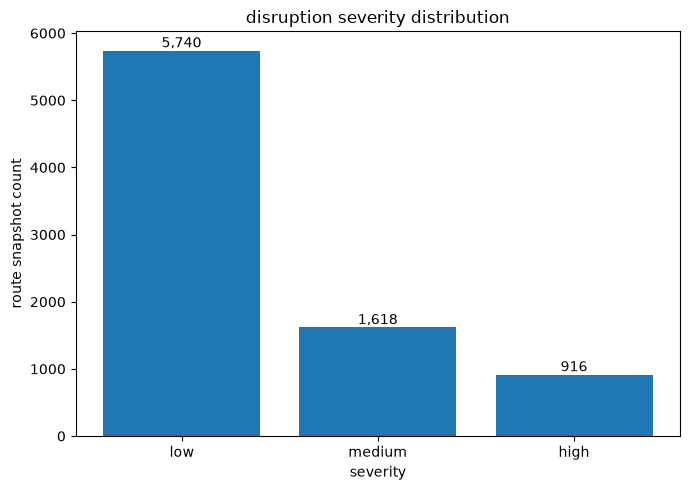

In [20]:
# count low medium and high severity records

severity_summary_df = (
    feature_df
    .groupBy(
        "severity_label",
        "severity_name"
    )
    .count()
    .orderBy(
        "severity_label"
    )
)

severity_summary_df.show(
    truncate=False
)

# convert the small summary to pandas

severity_pdf = (
    severity_summary_df
    .toPandas()
    .sort_values(
        "severity_label"
    )
)

# create the chart

plt.figure(
    figsize=(
        7,
        5
    )
)

bars = plt.bar(
    severity_pdf[
        "severity_name"
    ],
    severity_pdf[
        "count"
    ]
)

plt.title(
    "disruption severity distribution"
)

plt.xlabel(
    "severity"
)

plt.ylabel(
    "route snapshot count"
)

for bar in bars:
    plt.text(
        bar.get_x()
        +
        bar.get_width()
        /
        2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

severity_figure_path = (
    visualization_folder
    / "01_severity_distribution.png"
)

plt.savefig(
    severity_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    severity_figure_path
)

plt.show()

plt.close()

+----------------+-------------+-----+
|observation_hour|severity_name|count|
+----------------+-------------+-----+
|5               |high         |187  |
|5               |low          |159  |
|5               |medium       |98   |
|6               |high         |66   |
|6               |low          |109  |
|6               |medium       |68   |
|7               |high         |91   |
|7               |low          |708  |
|7               |medium       |229  |
|8               |high         |88   |
|8               |low          |1216 |
|8               |medium       |293  |
|9               |high         |110  |
|9               |low          |1141 |
|9               |medium       |245  |
|10              |high         |144  |
|10              |low          |1013 |
|10              |medium       |335  |
|11              |high         |92   |
|11              |low          |293  |
|11              |medium       |107  |
|14              |high         |43   |
|14              |low    

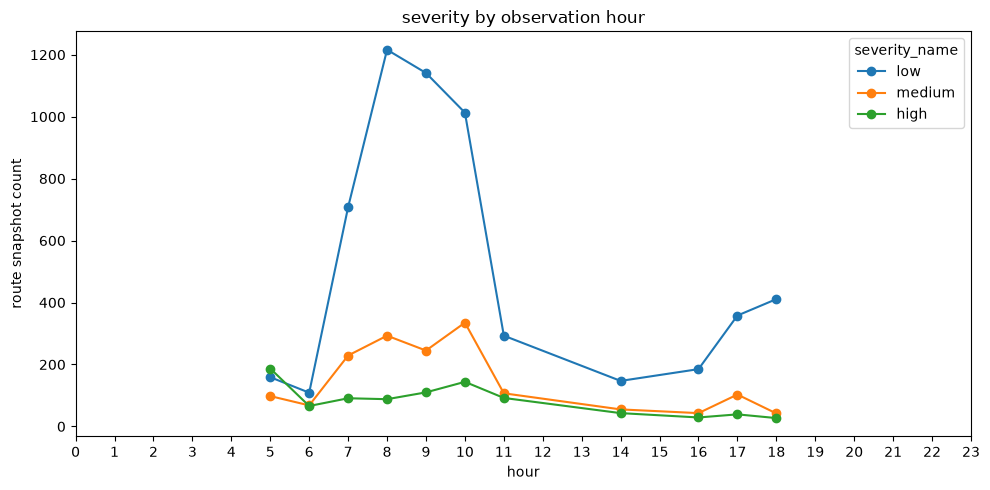

In [21]:
# count severity records for each hour

hour_severity_df = (
    feature_df
    .groupBy(
        "observation_hour",
        "severity_name"
    )
    .count()
    .orderBy(
        "observation_hour",
        "severity_name"
    )
)

hour_severity_df.show(
    50,
    truncate=False
)

# convert the summary to pandas

hour_severity_pdf = (
    hour_severity_df
    .toPandas()
)

hour_pivot = (
    hour_severity_pdf
    .pivot(
        index="observation_hour",
        columns="severity_name",
        values="count"
    )
    .fillna(
        0
    )
)

for severity_name in [
    "low",
    "medium",
    "high"
]:
    if severity_name not in hour_pivot.columns:
        hour_pivot[
            severity_name
        ] = 0

hour_pivot = hour_pivot[
    [
        "low",
        "medium",
        "high"
    ]
]

# create the chart

hour_pivot.plot(
    kind="line",
    marker="o",
    figsize=(
        10,
        5
    )
)

plt.title(
    "severity by observation hour"
)

plt.xlabel(
    "hour"
)

plt.ylabel(
    "route snapshot count"
)

plt.xticks(
    range(
        0,
        24
    )
)

plt.tight_layout()

hour_figure_path = (
    visualization_folder
    / "02_severity_by_hour.png"
)

plt.savefig(
    hour_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    hour_figure_path
)

plt.show()

plt.close()

+------------+-------------+-----+
|is_peak_hour|severity_name|count|
+------------+-------------+-----+
|0           |high         |532  |
|0           |low          |1721 |
|0           |medium       |663  |
|1           |high         |384  |
|1           |low          |4019 |
|1           |medium       |955  |
+------------+-------------+-----+

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda/03_peak_and_non_peak_severity.png


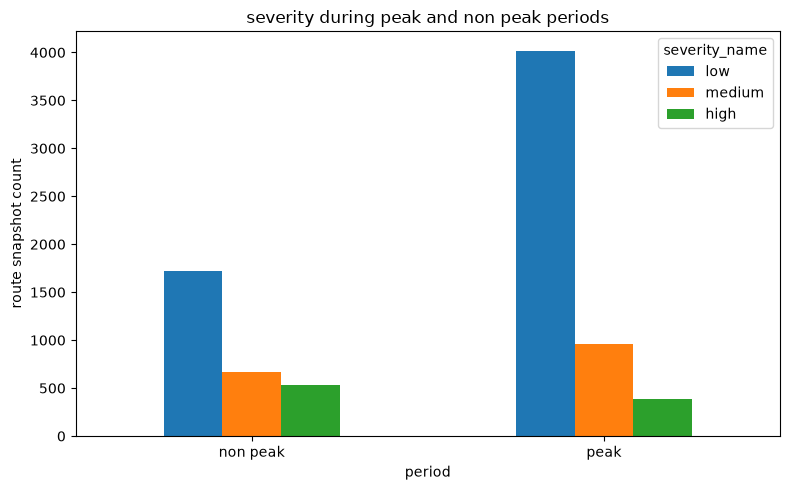

In [22]:
# compare peak and non peak severity

peak_severity_df = (
    feature_df
    .groupBy(
        "is_peak_hour",
        "severity_name"
    )
    .count()
    .orderBy(
        "is_peak_hour",
        "severity_name"
    )
)

peak_severity_df.show(
    truncate=False
)

peak_pdf = (
    peak_severity_df
    .toPandas()
)

peak_pdf[
    "period"
] = peak_pdf[
    "is_peak_hour"
].map(
    {
        0: "non peak",
        1: "peak"
    }
)

peak_pivot = (
    peak_pdf
    .pivot(
        index="period",
        columns="severity_name",
        values="count"
    )
    .fillna(
        0
    )
)

for severity_name in [
    "low",
    "medium",
    "high"
]:
    if severity_name not in peak_pivot.columns:
        peak_pivot[
            severity_name
        ] = 0

peak_pivot = peak_pivot[
    [
        "low",
        "medium",
        "high"
    ]
]

peak_pivot.plot(
    kind="bar",
    figsize=(
        8,
        5
    )
)

plt.title(
    "severity during peak and non peak periods"
)

plt.xlabel(
    "period"
)

plt.ylabel(
    "route snapshot count"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

peak_figure_path = (
    visualization_folder
    / "03_peak_and_non_peak_severity.png"
)

plt.savefig(
    peak_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    peak_figure_path
)

plt.show()

plt.close()

+----------+-------------+-----+
|is_weekend|severity_name|count|
+----------+-------------+-----+
|0         |high         |812  |
|0         |low          |5437 |
|0         |medium       |1576 |
|1         |high         |104  |
|1         |low          |303  |
|1         |medium       |42   |
+----------+-------------+-----+

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda/04_weekday_and_weekend_severity.png


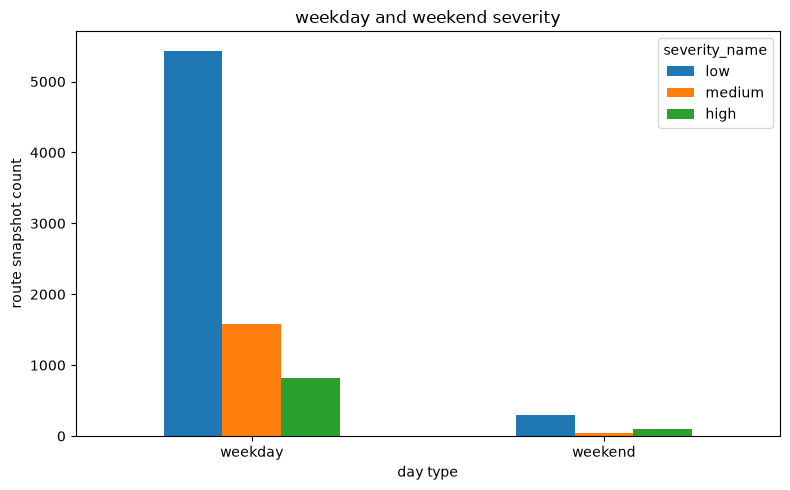

In [23]:
# compare weekday and weekend severity

weekend_severity_df = (
    feature_df
    .groupBy(
        "is_weekend",
        "severity_name"
    )
    .count()
    .orderBy(
        "is_weekend",
        "severity_name"
    )
)

weekend_severity_df.show(
    truncate=False
)

weekend_pdf = (
    weekend_severity_df
    .toPandas()
)

weekend_pdf[
    "day_type"
] = weekend_pdf[
    "is_weekend"
].map(
    {
        0: "weekday",
        1: "weekend"
    }
)

weekend_pivot = (
    weekend_pdf
    .pivot(
        index="day_type",
        columns="severity_name",
        values="count"
    )
    .fillna(
        0
    )
)

for severity_name in [
    "low",
    "medium",
    "high"
]:
    if severity_name not in weekend_pivot.columns:
        weekend_pivot[
            severity_name
        ] = 0

weekend_pivot = weekend_pivot[
    [
        "low",
        "medium",
        "high"
    ]
]

weekend_pivot.plot(
    kind="bar",
    figsize=(
        8,
        5
    )
)

plt.title(
    "weekday and weekend severity"
)

plt.xlabel(
    "day type"
)

plt.ylabel(
    "route snapshot count"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

weekend_figure_path = (
    visualization_folder
    / "04_weekday_and_weekend_severity.png"
)

plt.savefig(
    weekend_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    weekend_figure_path
)

plt.show()

plt.close()

+----------+-------------+-----+
|route_name|direction_ref|count|
+----------+-------------+-----+
|18        |outbound     |20   |
|15        |inbound      |20   |
|6A        |inbound      |18   |
|37        |outbound     |13   |
|60        |inbound      |12   |
|6A        |outbound     |11   |
|13        |outbound     |11   |
|14        |outbound     |10   |
|31        |outbound     |10   |
|52        |inbound      |10   |
+----------+-------------+-----+

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda/05_top_high_severity_routes.png


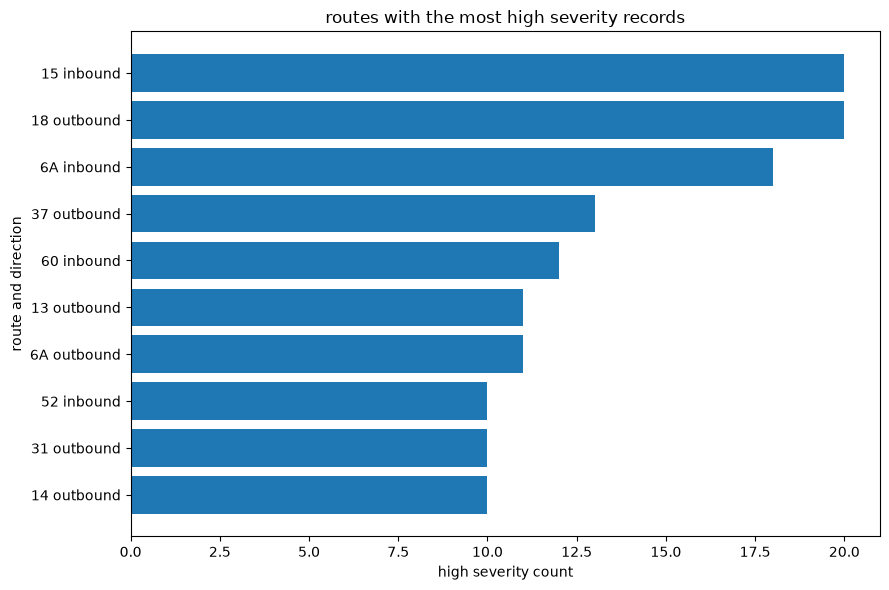

In [24]:
# find routes with the most high severity records

top_high_route_df = (
    feature_df
    .filter(
        F.col(
            "severity_name"
        )
        ==
        "high"
    )
    .withColumn(
        "route_name",
        F.coalesce(
            F.col(
                "published_line_name"
            ),
            F.col(
                "line_ref"
            )
        )
    )
    .groupBy(
        "route_name",
        "direction_ref"
    )
    .count()
    .orderBy(
        F.desc(
            "count"
        )
    )
    .limit(
        10
    )
)

top_high_route_df.show(
    truncate=False
)

top_high_route_pdf = (
    top_high_route_df
    .toPandas()
)

top_high_route_pdf[
    "route_direction"
] = (
    top_high_route_pdf[
        "route_name"
    ].astype(
        str
    )
    +
    " "
    +
    top_high_route_pdf[
        "direction_ref"
    ].astype(
        str
    )
)

top_high_route_pdf = (
    top_high_route_pdf
    .sort_values(
        "count",
        ascending=True
    )
)

plt.figure(
    figsize=(
        9,
        6
    )
)

plt.barh(
    top_high_route_pdf[
        "route_direction"
    ],
    top_high_route_pdf[
        "count"
    ]
)

plt.title(
    "routes with the most high severity records"
)

plt.xlabel(
    "high severity count"
)

plt.ylabel(
    "route and direction"
)

plt.tight_layout()

route_figure_path = (
    visualization_folder
    / "05_top_high_severity_routes.png"
)

plt.savefig(
    route_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    route_figure_path
)

plt.show()

plt.close()

+--------------+-------------+---------------------+----------------------+---------------------+--------------------------+----------------------+-----------------------------+
|severity_label|severity_name|average_vehicle_count|average_activity_ratio|average_spacing_ratio|average_activity_shortfall|average_spacing_excess|average_previous_vehicle_drop|
+--------------+-------------+---------------------+----------------------+---------------------+--------------------------+----------------------+-----------------------------+
|0             |low          |5.2                  |1.111                 |0.713                |0.027                     |0.034                 |0.016                        |
|1             |medium       |4.485                |0.855                 |0.95                 |0.195                     |0.242                 |0.077                        |
|2             |high         |3.618                |0.785                 |1.916                |0.31         

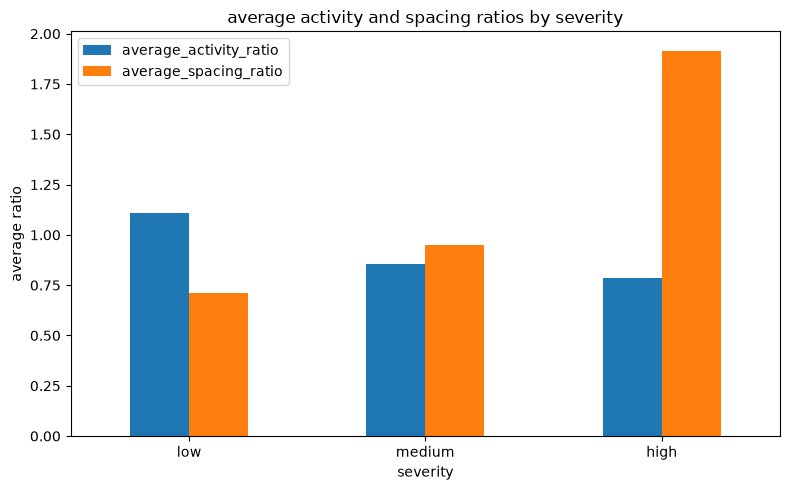

In [25]:
# calculate average feature values for each severity

feature_average_df = (
    feature_df
    .groupBy(
        "severity_label",
        "severity_name"
    )
    .agg(
        F.round(
            F.avg(
                "observed_vehicle_count"
            ),
            3
        ).alias(
            "average_vehicle_count"
        ),
        F.round(
            F.avg(
                "activity_ratio"
            ),
            3
        ).alias(
            "average_activity_ratio"
        ),
        F.round(
            F.avg(
                "spacing_ratio"
            ),
            3
        ).alias(
            "average_spacing_ratio"
        ),
        F.round(
            F.avg(
                "activity_shortfall"
            ),
            3
        ).alias(
            "average_activity_shortfall"
        ),
        F.round(
            F.avg(
                "spacing_excess"
            ),
            3
        ).alias(
            "average_spacing_excess"
        ),
        F.round(
            F.avg(
                "previous_vehicle_drop"
            ),
            3
        ).alias(
            "average_previous_vehicle_drop"
        )
    )
    .orderBy(
        "severity_label"
    )
)

feature_average_df.show(
    truncate=False
)

feature_average_pdf = (
    feature_average_df
    .toPandas()
    .sort_values(
        "severity_label"
    )
)

ratio_chart_df = (
    feature_average_pdf
    .set_index(
        "severity_name"
    )[
        [
            "average_activity_ratio",
            "average_spacing_ratio"
        ]
    ]
)

ratio_chart_df.plot(
    kind="bar",
    figsize=(
        8,
        5
    )
)

plt.title(
    "average activity and spacing ratios by severity"
)

plt.xlabel(
    "severity"
)

plt.ylabel(
    "average ratio"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

feature_figure_path = (
    visualization_folder
    / "06_activity_and_spacing_by_severity.png"
)

plt.savefig(
    feature_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    feature_figure_path
)

plt.show()

plt.close()

model eligible rows: 6,014
+---------------------+--------------------+-----+----------+
|target_severity_label|target_severity_name|count|percentage|
+---------------------+--------------------+-----+----------+
|0                    |low                 |4306 |71.6      |
|1                    |medium              |1210 |20.12     |
|2                    |high                |498  |8.28      |
+---------------------+--------------------+-----+----------+

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda/07_model_target_distribution.png


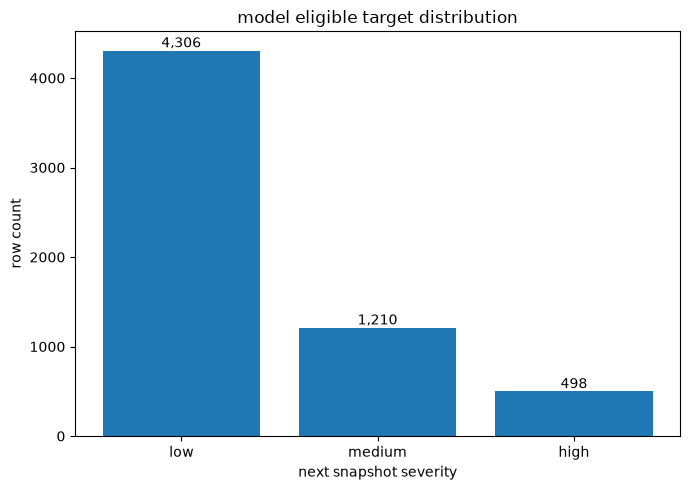

In [26]:
# keep only rows suitable for machine learning

eligible_model_df = (
    model_df
    .filter(
        F.col(
            "model_eligible_flag"
        )
        ==
        1
    )
    .cache()
)

eligible_rows = eligible_model_df.count()

print(
    "model eligible rows:",
    f"{eligible_rows:,}"
)

# count the target classes

eligible_target_df = (
    eligible_model_df
    .groupBy(
        "target_severity_label",
        "target_severity_name"
    )
    .count()
    .withColumn(
        "percentage",
        F.round(
            F.col(
                "count"
            )
            /
            F.lit(
                eligible_rows
            )
            *
            100,
            2
        )
    )
    .orderBy(
        "target_severity_label"
    )
)

eligible_target_df.show(
    truncate=False
)

eligible_target_pdf = (
    eligible_target_df
    .toPandas()
    .sort_values(
        "target_severity_label"
    )
)

plt.figure(
    figsize=(
        7,
        5
    )
)

bars = plt.bar(
    eligible_target_pdf[
        "target_severity_name"
    ],
    eligible_target_pdf[
        "count"
    ]
)

plt.title(
    "model eligible target distribution"
)

plt.xlabel(
    "next snapshot severity"
)

plt.ylabel(
    "row count"
)

for bar in bars:
    plt.text(
        bar.get_x()
        +
        bar.get_width()
        /
        2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

target_figure_path = (
    visualization_folder
    / "07_model_target_distribution.png"
)

plt.savefig(
    target_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    target_figure_path
)

plt.show()

plt.close()

26/07/16 23:15:06 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/16 23:15:06 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


                        observation_hour  is_peak_hour  is_weekend  \
observation_hour                   1.000        -0.218         NaN   
is_peak_hour                      -0.218         1.000         NaN   
is_weekend                           NaN           NaN         1.0   
observed_vehicle_count             0.011        -0.014         NaN   
observed_journey_count             0.011        -0.014         NaN   
exact_match_rate                   0.020         0.001         NaN   
fallback_match_rate               -0.020        -0.001         NaN   
activity_ratio                     0.036         0.027         NaN   
spacing_ratio                      0.024        -0.249         NaN   
activity_shortfall                -0.026         0.002         NaN   
spacing_excess                    -0.002        -0.155         NaN   
previous_vehicle_drop             -0.054         0.026         NaN   
single_vehicle_flag               -0.005        -0.008         NaN   
target_severity_labe

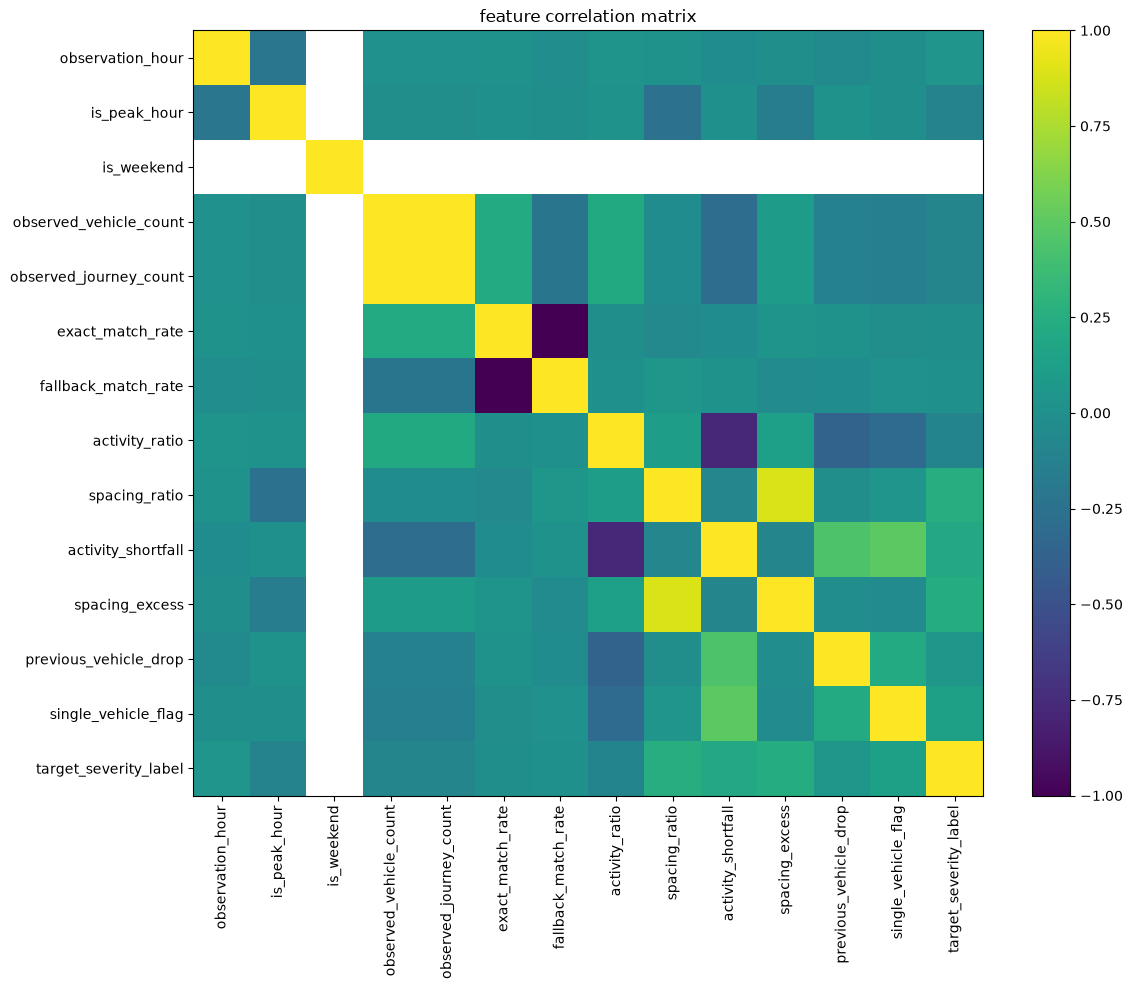

In [27]:
# define numerical correlation columns

correlation_columns = [
    "observation_hour",
    "is_peak_hour",
    "is_weekend",
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop",
    "single_vehicle_flag",
    "target_severity_label"
]

# prepare the correlation data

correlation_source_df = (
    eligible_model_df
    .select(
        *correlation_columns
    )
    .fillna(
        0.0
    )
)

assembler = VectorAssembler(
    inputCols=correlation_columns,
    outputCol="correlation_features",
    handleInvalid="skip"
)

correlation_vector_df = (
    assembler
    .transform(
        correlation_source_df
    )
    .select(
        "correlation_features"
    )
)

# calculate the correlation matrix

correlation_matrix = (
    Correlation
    .corr(
        correlation_vector_df,
        "correlation_features",
        "pearson"
    )
    .head()[0]
    .toArray()
)

correlation_pdf = pd.DataFrame(
    correlation_matrix,
    index=correlation_columns,
    columns=correlation_columns
)

print(
    correlation_pdf.round(
        3
    )
)

# display the correlation matrix

plt.figure(
    figsize=(
        12,
        10
    )
)

plt.imshow(
    correlation_pdf.values,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(
        len(
            correlation_columns
        )
    ),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(
        len(
            correlation_columns
        )
    ),
    correlation_columns
)

plt.title(
    "feature correlation matrix"
)

plt.tight_layout()

correlation_figure_path = (
    visualization_folder
    / "08_feature_correlation_matrix.png"
)

plt.savefig(
    correlation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "saved:",
    correlation_figure_path
)

plt.show()

plt.close()

In [28]:
# save severity summary

(
    severity_summary_df
    .coalesce(
        1
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            eda_output_path
            /
            "severity_summary"
        )
    )
)

# save hourly severity summary

(
    hour_severity_df
    .coalesce(
        1
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            eda_output_path
            /
            "hour_severity_summary"
        )
    )
)

# save high severity route summary

(
    top_high_route_df
    .coalesce(
        1
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            eda_output_path
            /
            "high_severity_routes"
        )
    )
)

# save feature average summary

(
    feature_average_df
    .coalesce(
        1
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            eda_output_path
            /
            "feature_average_summary"
        )
    )
)

# save model target summary

(
    eligible_target_df
    .coalesce(
        1
    )
    .write
    .mode(
        "overwrite"
    )
    .option(
        "header",
        True
    )
    .csv(
        str(
            eda_output_path
            /
            "model_target_summary"
        )
    )
)

# save the correlation matrix

correlation_pdf.to_csv(
    eda_output_path
    /
    "correlation_matrix.csv"
)

print(
    "EDA summary files saved"
)

print(
    "output folder:",
    eda_output_path
)

EDA summary files saved
output folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/eda_outputs


In [30]:
# find the largest severity class

largest_severity_row = (
    severity_summary_df
    .orderBy(
        F.desc(
            "count"
        )
    )
    .first()
)

# find the hour with the most high severity records

highest_high_hour_row = (
    hour_severity_df
    .filter(
        F.col(
            "severity_name"
        )
        ==
        "high"
    )
    .orderBy(
        F.desc(
            "count"
        )
    )
    .first()
)

# find the top high severity route

top_route_row = (
    top_high_route_df
    .first()
)

print(
    "EDA completed successfully"
)

print(
    "largest severity class:",
    largest_severity_row[
        "severity_name"
    ],
    largest_severity_row[
        "count"
    ]
)

print(
    "hour with the most high severity records:",
    highest_high_hour_row[
        "observation_hour"
    ],
    highest_high_hour_row[
        "count"
    ]
)

print(
    "route with the most high severity records:",
    top_route_row[
        "route_name"
    ],
    top_route_row[
        "direction_ref"
    ],
    top_route_row[
        "count"
    ]
)

print(
    "visualizations saved in:",
    visualization_folder
)


EDA completed successfully
largest severity class: low 5740
hour with the most high severity records: 5 187
route with the most high severity records: 18 outbound 20
visualizations saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/eda
